# IT3051 Mini Project: Hotel Booking Cancellation Prediction

This notebook follows the full data mining workflow from Stage 1 to Stage 5:
- Problem understanding
- Dataset validation
- Exploratory data analysis
- Data preprocessing and feature engineering
- Train/test preparation

The target is `is_canceled` and the task is binary classification.

In [ ]:
                                                # Cell 2 - Imports and setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print('Libraries imported successfully.')
print('Notebook ready for hotel booking analysis.')

Libraries imported successfully.
Notebook ready for hotel booking analysis.


In [5]:
# Cell 3 - Load the dataset
file_path = 'hotel_bookings.csv'
df = pd.read_csv(file_path)

print('Dataset shape:', df.shape)
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])

Dataset shape: (119390, 32)
Number of rows: 119390
Number of columns: 32


In [6]:
# Cell 4 - Preview the dataset
df.head().to_string(index=False)

'       hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  adults  children  babies meal country market_segment distribution_channel  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled reserved_room_type assigned_room_type  booking_changes deposit_type  agent  company  days_in_waiting_list customer_type  adr  required_car_parking_spaces  total_of_special_requests reservation_status reservation_status_date\nResort Hotel            0        342               2015               July                        27                          1                        0                     0       2       0.0       0   BB     PRT         Direct               Direct                  0                       0                               0                  C                  C                3   No Deposit    NaN      NaN                     0     Transient  0.0

In [7]:
# Cell 5 - Show column names
list(df.columns)

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [8]:
# Cell 6 - Check data types
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [9]:
# Cell 7 - Basic information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [10]:
# Cell 8 - Check missing values
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

company     112593
agent        16340
country        488
children         4
dtype: int64

In [11]:
# Cell 9 - Check duplicate records
df.duplicated().sum()

np.int64(31994)

In [12]:
# Cell 10 - Inspect target variable distribution
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [13]:
# Cell 11 - Check target proportion
df['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

## Data Understanding and Exploratory Data Analysis (EDA)

This section focuses on understanding the structure, quality, and relationships within the dataset before building predictive models.

We will inspect:
- dataset shape and variables
- missing values and duplicates
- target distribution
- key business and behavioral patterns
- relationships between booking features and cancellation behavior

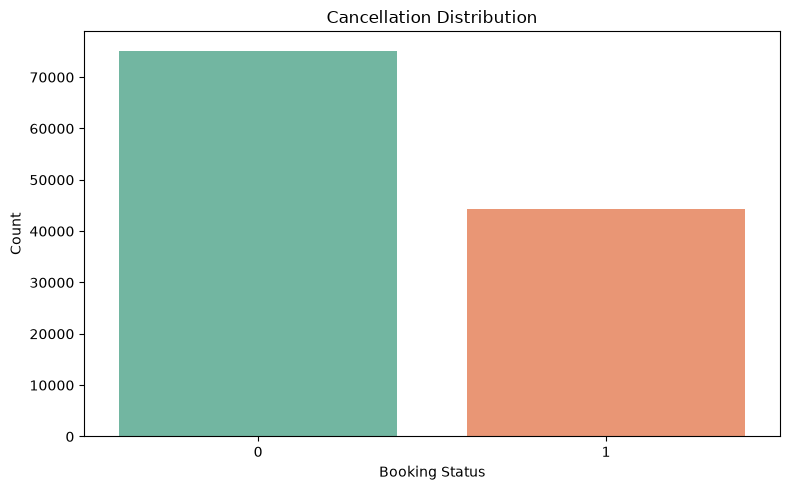

In [14]:
# Cell 12 - Visualization 1: cancellation target balance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='is_canceled', palette='Set2')
plt.title('Cancellation Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

hotel
City Hotel      0.417270
Resort Hotel    0.277634
Name: is_canceled, dtype: float64


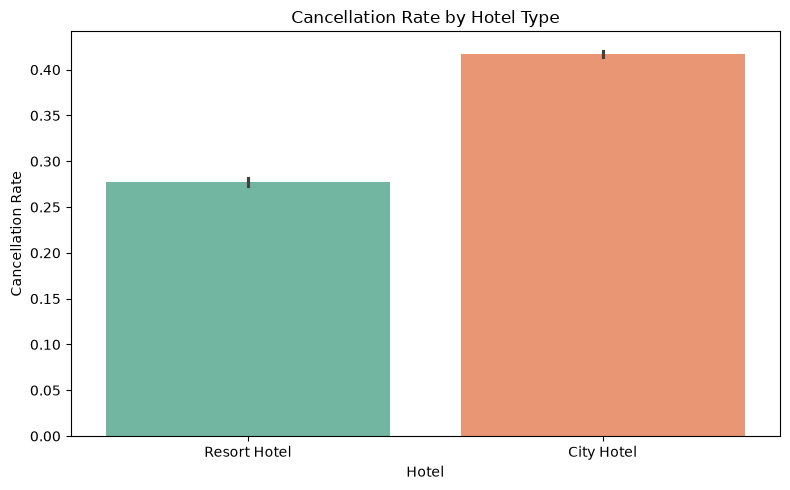

In [15]:
# Cell 13 - Group cancellation rate by hotel type
hotel_rate = df.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)
print(hotel_rate)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='hotel', y='is_canceled', estimator='mean', palette='Set2')
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

arrival_date_month
January      0.304773
February     0.334160
March        0.321523
April        0.407972
May          0.396658
June         0.414572
July         0.374536
August       0.377531
September    0.391702
October      0.380466
November     0.312334
December     0.349705
Name: is_canceled, dtype: float64


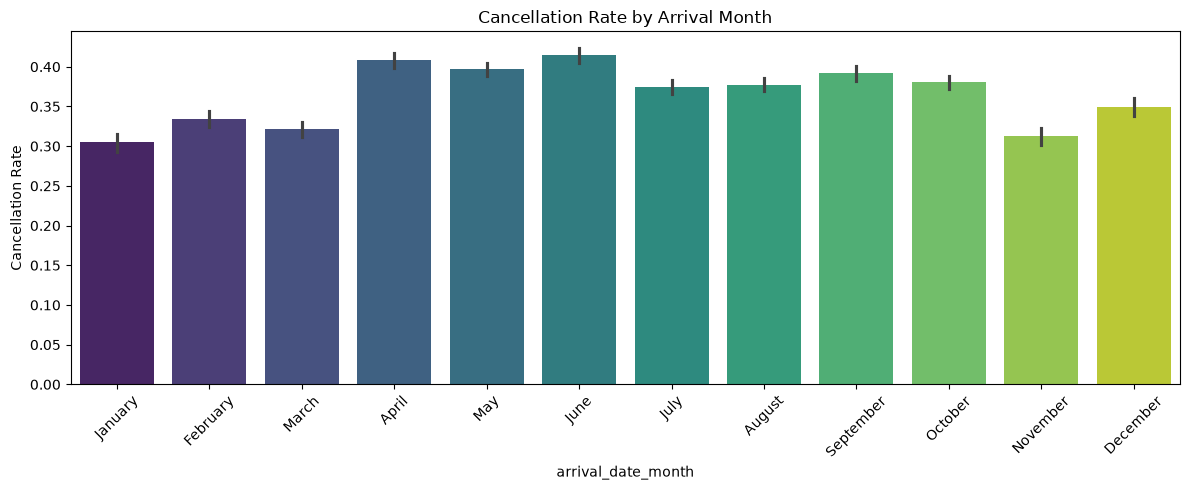

In [16]:
# Cell 14 - Month-wise cancellation patterns
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_rate = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)
print(monthly_rate)

plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='arrival_date_month', y='is_canceled', estimator='mean', order=month_order, palette='viridis')
plt.title('Cancellation Rate by Arrival Month')
plt.xticks(rotation=45)
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

customer_type
Transient          0.407463
Contract           0.309617
Transient-Party    0.254299
Group              0.102253
Name: is_canceled, dtype: float64


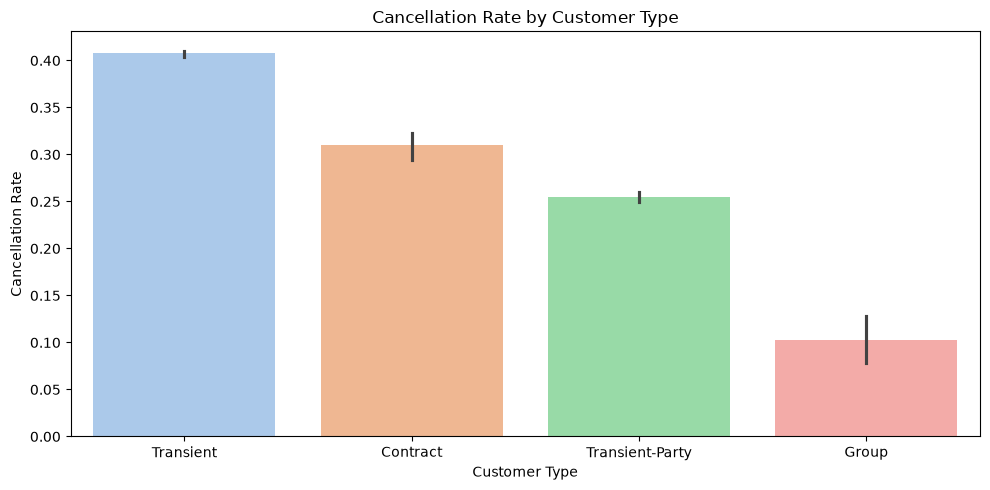

In [17]:
# Cell 15 - Customer type analysis
customer_rate = df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False)
print(customer_rate)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='customer_type', y='is_canceled', estimator='mean', palette='pastel')
plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

market_segment
Undefined        1.000000
Groups           0.610620
Online TA        0.367211
Offline TA/TO    0.343160
Aviation         0.219409
Corporate        0.187347
Direct           0.153419
Complementary    0.130552
Name: is_canceled, dtype: float64


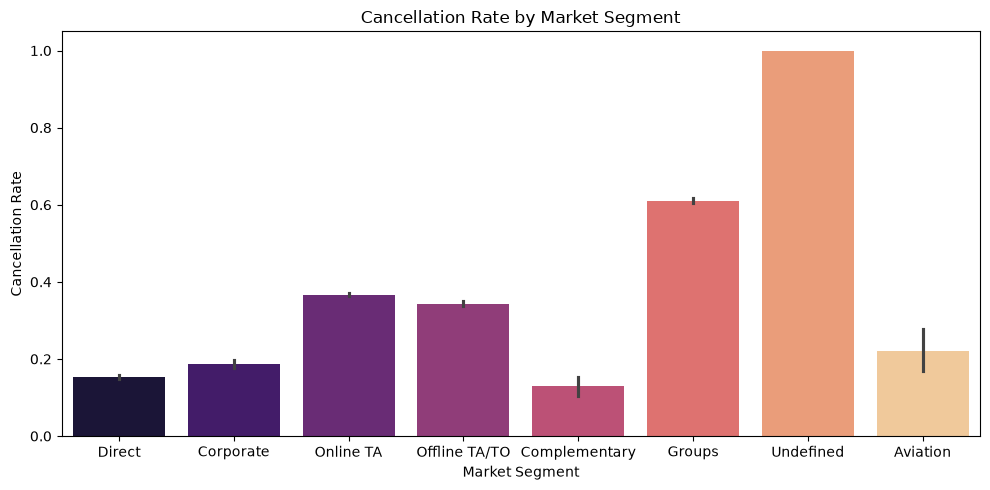

In [18]:
# Cell 16 - Market segment analysis
market_rate = df.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)
print(market_rate)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='market_segment', y='is_canceled', estimator='mean', palette='magma')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

deposit_type
Non Refund    0.993624
No Deposit    0.283770
Refundable    0.222222
Name: is_canceled, dtype: float64


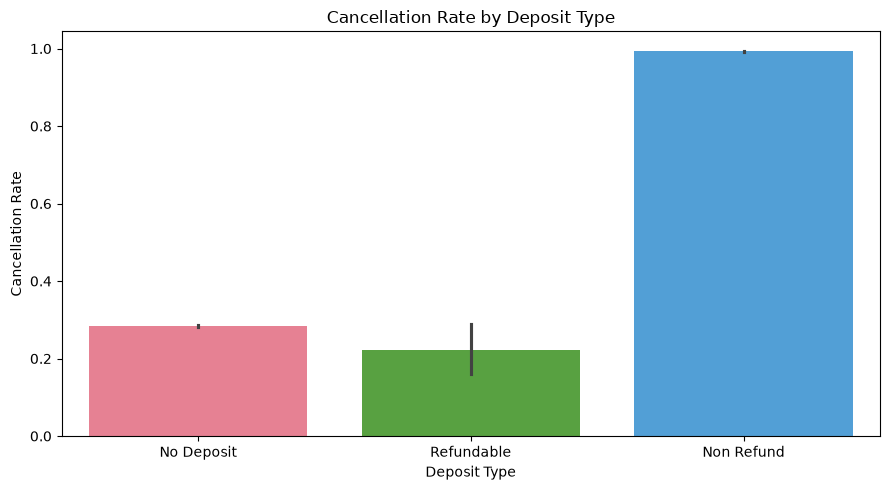

In [19]:
# Cell 17 - Deposit type analysis
deposit_rate = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)
print(deposit_rate)

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='deposit_type', y='is_canceled', estimator='mean', palette='husl')
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

distribution_channel
Undefined    0.800000
TA/TO        0.410259
Corporate    0.220758
GDS          0.191710
Direct       0.174599
Name: is_canceled, dtype: float64


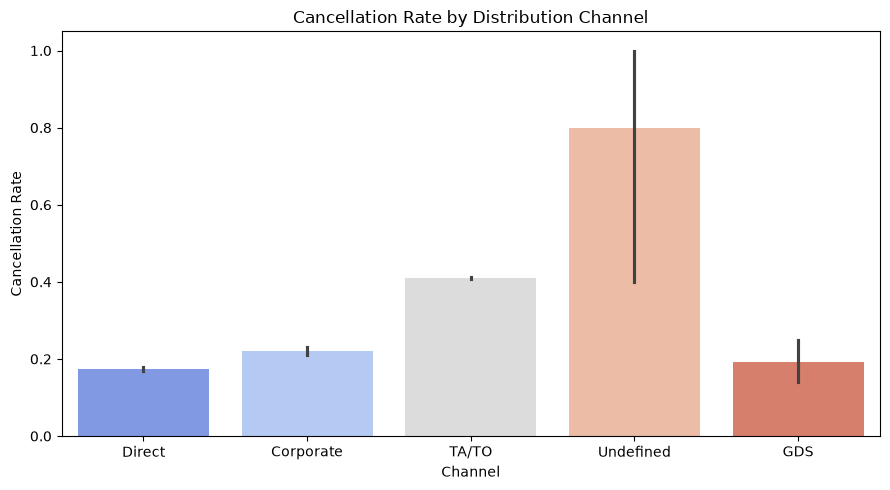

In [20]:
# Cell 18 - Distribution channel analysis
channel_rate = df.groupby('distribution_channel')['is_canceled'].mean().sort_values(ascending=False)
print(channel_rate)

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='distribution_channel', y='is_canceled', estimator='mean', palette='coolwarm')
plt.title('Cancellation Rate by Distribution Channel')
plt.xlabel('Channel')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

reserved_room_type
P    1.000000
H    0.407654
A    0.391074
G    0.364374
L    0.333333
C    0.330472
B    0.329159
D    0.317796
F    0.303763
E    0.292884
Name: is_canceled, dtype: float64


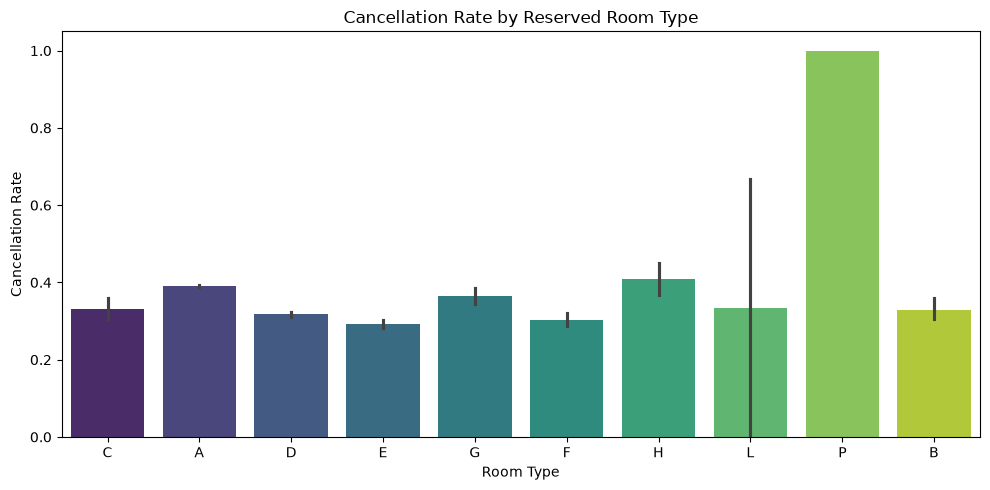

In [21]:
# Cell 19 - Room type analysis
room_rate = df.groupby('reserved_room_type')['is_canceled'].mean().sort_values(ascending=False)
print(room_rate)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='reserved_room_type', y='is_canceled', estimator='mean', palette='viridis')
plt.title('Cancellation Rate by Reserved Room Type')
plt.xlabel('Room Type')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

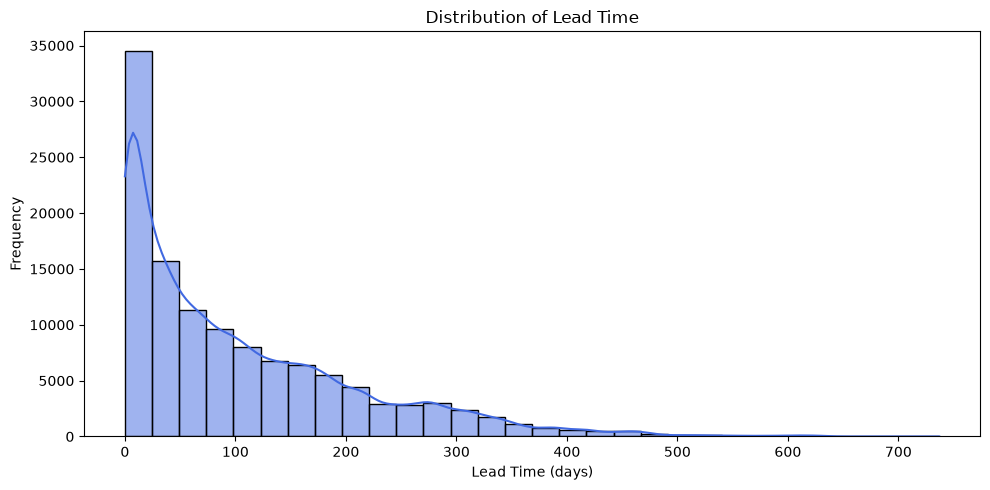

In [22]:
# Cell 20 - Lead time distribution and business meaning
plt.figure(figsize=(10, 5))
sns.histplot(df['lead_time'], bins=30, kde=True, color='royalblue')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

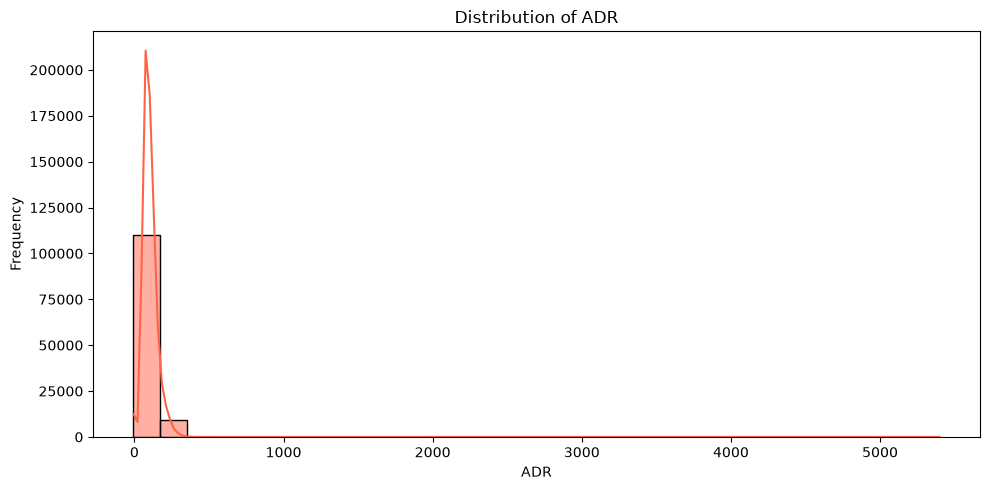

In [23]:
# Cell 21 - ADR distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['adr'], bins=30, kde=True, color='tomato')
plt.title('Distribution of ADR')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

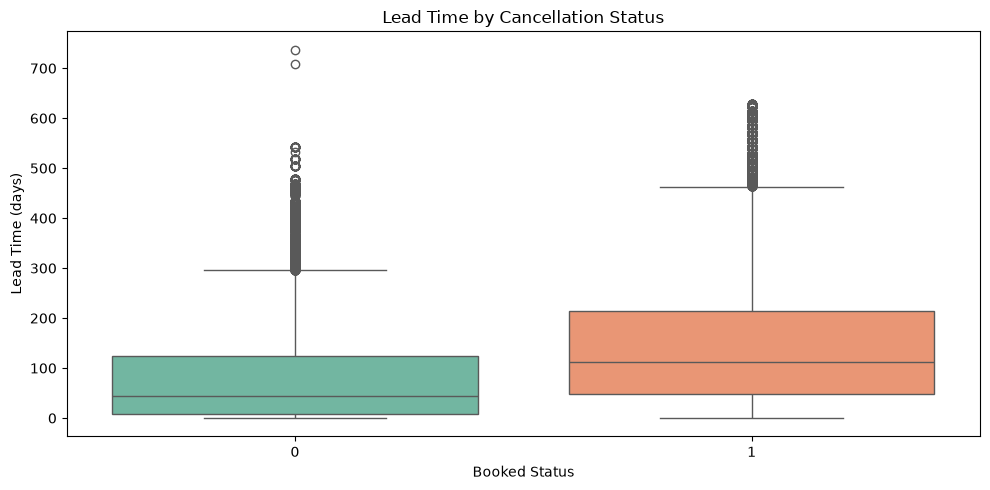

In [24]:
# Cell 22 - Lead time comparison by cancellation status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set2')
plt.title('Lead Time by Cancellation Status')
plt.xlabel('Booked Status')
plt.ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

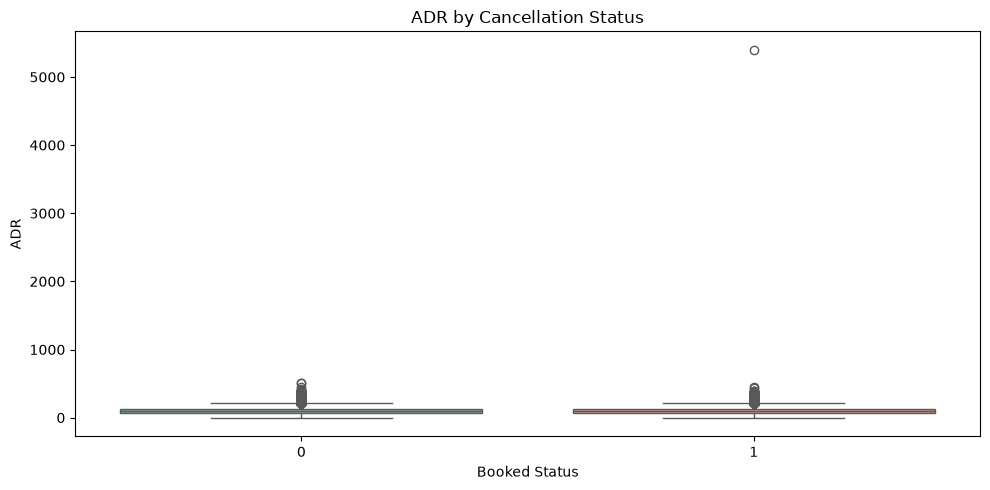

In [25]:
# Cell 23 - ADR comparison by cancellation status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_canceled', y='adr', palette='Set2')
plt.title('ADR by Cancellation Status')
plt.xlabel('Booked Status')
plt.ylabel('ADR')
plt.tight_layout()
plt.show()

In [26]:
# Cell 24 - Compute stay length feature
# This is a useful derived variable for later modeling.
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
print(df[['stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights']].head())

   stays_in_weekend_nights  stays_in_week_nights  total_nights
0                        0                     0             0
1                        0                     0             0
2                        0                     1             1
3                        0                     1             1
4                        0                     2             2


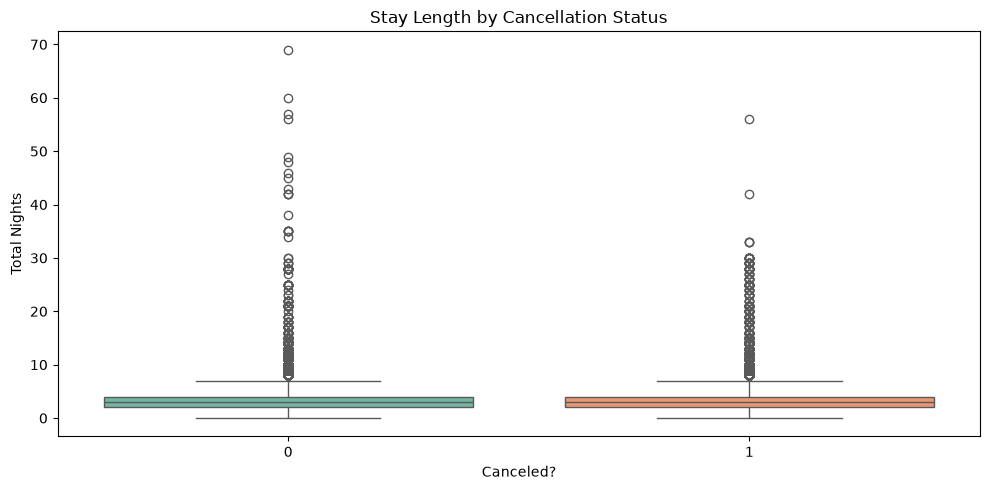

In [27]:
# Cell 25 - Stay length by cancellation status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_canceled', y='total_nights', palette='Set2')
plt.title('Stay Length by Cancellation Status')
plt.xlabel('Canceled?')
plt.ylabel('Total Nights')
plt.tight_layout()
plt.show()

is_canceled
0    0.714060
1    0.328826
Name: total_of_special_requests, dtype: float64


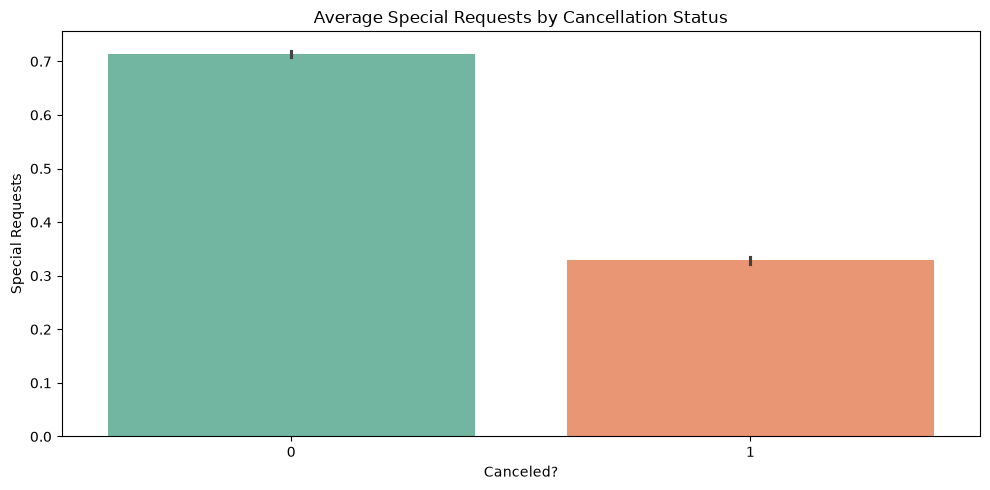

In [28]:
# Cell 26 - Special requests and cancellation relationship
special_request_rate = df.groupby('is_canceled')['total_of_special_requests'].mean()
print(special_request_rate)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='is_canceled', y='total_of_special_requests', estimator='mean', palette='Set2')
plt.title('Average Special Requests by Cancellation Status')
plt.xlabel('Canceled?')
plt.ylabel('Special Requests')
plt.tight_layout()
plt.show()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64


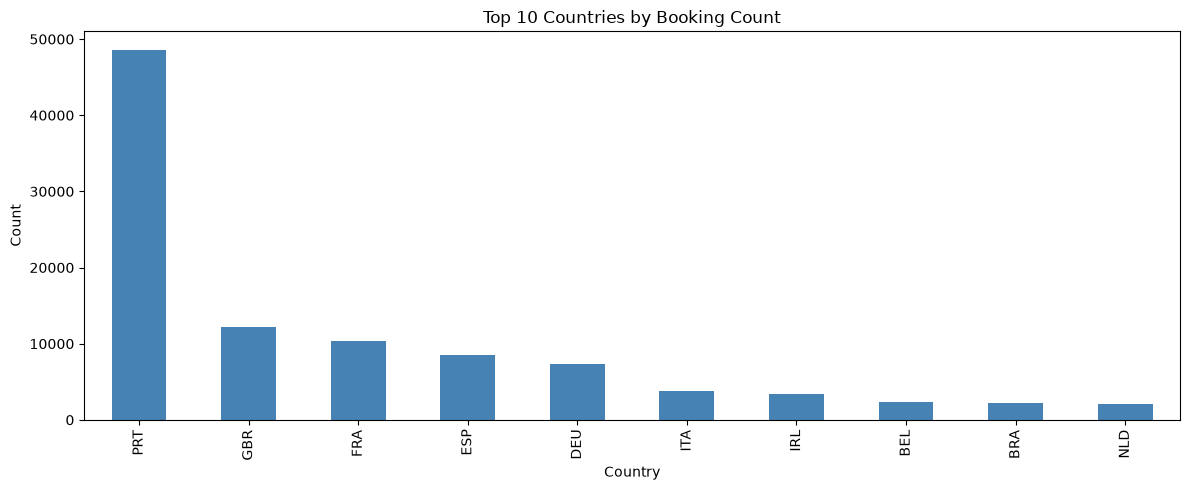

In [29]:
# Cell 27 - Country concentration
country_counts = df['country'].value_counts().head(10)
print(country_counts)

plt.figure(figsize=(12, 5))
country_counts.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Booking Count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [30]:
# Cell 28 - Missing values in agent and company columns
print('Agent missing %:', round(df['agent'].isna().mean() * 100, 2))
print('Company missing %:', round(df['company'].isna().mean() * 100, 2))
print(df[['agent', 'company']].isna().sum())

Agent missing %: 13.69
Company missing %: 94.31
agent       16340
company    112593
dtype: int64


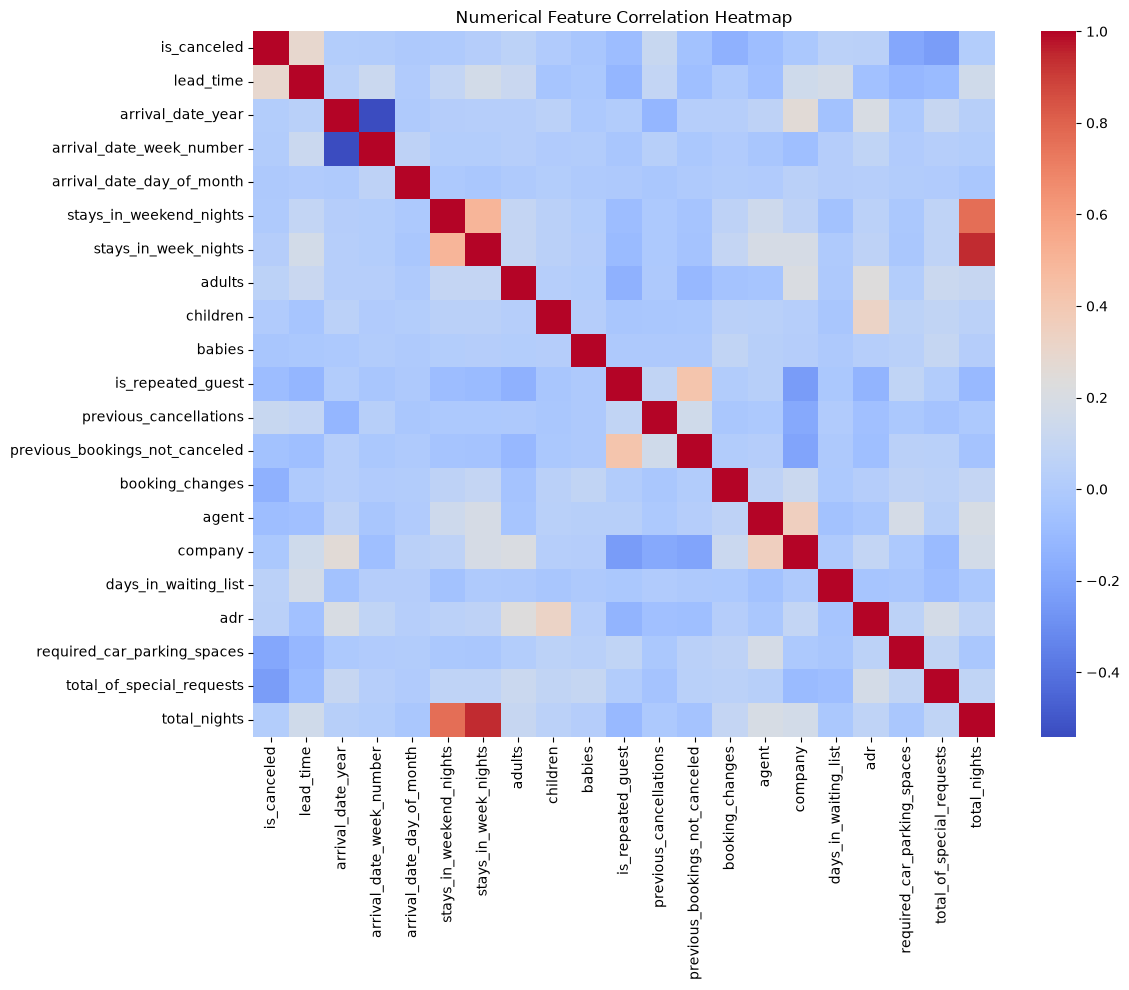

In [31]:
# Cell 29 - Correlation heatmap for numerical features
numeric_corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_corr, cmap='coolwarm', annot=False)
plt.title('Numerical Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [32]:
# Cell 30 - Summary of numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)

['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights']


In [33]:
# Cell 31 - Summary statistics for key numeric variables
df[['lead_time', 'adr', 'total_nights', 'days_in_waiting_list']].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
total_nights,119390.0,3.427900,2.557439,0.00,2.00,3.000,4.0,69.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0


In [34]:
# Cell 32 - Check unique counts for some categorical variables
print('Unique hotels:', df['hotel'].nunique())
print('Unique countries:', df['country'].nunique())
print('Unique market segments:', df['market_segment'].nunique())
print('Unique customer types:', df['customer_type'].nunique())

Unique hotels: 2
Unique countries: 177
Unique market segments: 8
Unique customer types: 4


In [35]:
# Cell 33 - Leakage check
# These fields are outcome-related and must not be used as input features.
for col in ['reservation_status', 'reservation_status_date']:
    if col in df.columns:
        print(col, 'exists and should be excluded from prediction features.')

reservation_status exists and should be excluded from prediction features.
reservation_status_date exists and should be excluded from prediction features.


In [36]:
# Cell 34 - Result of the leakage review
print('The variable reservation_status tells us if the booking was already canceled or completed.')
print('Because it is a post-booking outcome, it would create data leakage if included in the model.')

The variable reservation_status tells us if the booking was already canceled or completed.
Because it is a post-booking outcome, it would create data leakage if included in the model.


In [37]:
# Cell 35 - Important EDA observation summary
print('Key findings from EDA:')
print('- Cancellation rate is not balanced across classes.')
print('- Hotel type, month, customer type, and market segment affect cancellations.')
print('- Lead time, deposit type, and ADR are strong behavioural signals.')
print('- Some fields such as reservation_status must be removed to avoid leakage.')

Key findings from EDA:
- Cancellation rate is not balanced across classes.
- Hotel type, month, customer type, and market segment affect cancellations.
- Lead time, deposit type, and ADR are strong behavioural signals.
- Some fields such as reservation_status must be removed to avoid leakage.


## Data Preprocessing and Feature Engineering

This stage prepares the dataset for model training by handling missing values, removing duplicates, eliminating leakage variables, and creating meaningful engineered features.

- train/test preparation for modeling

Key tasks include:- feature creation such as total stay length and lead-time indicators

- missing value treatment- leakage detection and removal
- duplicate record removal

In [38]:
# Cell 37 - Create a clean working copy
cleaned_df = df.copy()
print('Initial rows:', len(cleaned_df))

Initial rows: 119390


In [39]:
# Cell 38 - Remove duplicate rows
cleaned_df = cleaned_df.drop_duplicates()
print('Rows after duplicate removal:', len(cleaned_df))

Rows after duplicate removal: 87396


In [40]:
# Cell 39 - Fill missing values for children
cleaned_df['children'] = cleaned_df['children'].fillna(cleaned_df['children'].median())
print('Children missing after fill:', cleaned_df['children'].isna().sum())

Children missing after fill: 0


In [41]:
# Cell 40 - Handle categorical missing values
cleaned_df['country'] = cleaned_df['country'].fillna('Unknown')
cleaned_df['meal'] = cleaned_df['meal'].fillna('SC')
cleaned_df['market_segment'] = cleaned_df['market_segment'].fillna('Unknown')
cleaned_df['distribution_channel'] = cleaned_df['distribution_channel'].fillna('Unknown')
cleaned_df['customer_type'] = cleaned_df['customer_type'].fillna('Transient')
cleaned_df['deposit_type'] = cleaned_df['deposit_type'].fillna('No Deposit')

print('Categorical missing values reduced.')

Categorical missing values reduced.


In [42]:
# Cell 41 - Handle agent and company missing values
cleaned_df['agent'] = cleaned_df['agent'].fillna(0).astype(int)
cleaned_df['company'] = cleaned_df['company'].fillna(0).astype(int)
print('Agent nulls:', cleaned_df['agent'].isna().sum())
print('Company nulls:', cleaned_df['company'].isna().sum())

Agent nulls: 0
Company nulls: 0


In [43]:
# Cell 42 - Create engineered features
cleaned_df['total_nights'] = cleaned_df['stays_in_weekend_nights'] + cleaned_df['stays_in_week_nights']
cleaned_df['is_long_stay'] = (cleaned_df['total_nights'] > 7).astype(int)
cleaned_df['is_weekend_stay'] = (cleaned_df['stays_in_weekend_nights'] > 0).astype(int)
cleaned_df['is_high_lead_time'] = (cleaned_df['lead_time'] > 60).astype(int)

print(cleaned_df[['total_nights', 'is_long_stay', 'is_weekend_stay', 'is_high_lead_time']].head())

   total_nights  is_long_stay  is_weekend_stay  is_high_lead_time
0             0             0                0                  1
1             0             0                0                  1
2             1             0                0                  0
3             1             0                0                  0
4             2             0                0                  0


In [44]:
# Cell 43 - Drop leakage columns
leakage_cols = ['reservation_status', 'reservation_status_date']
cleaned_df = cleaned_df.drop(columns=leakage_cols, errors='ignore')
print('Leakage columns removed from the feature set.')
print('Remaining columns:', len(cleaned_df.columns))

Leakage columns removed from the feature set.
Remaining columns: 34


In [45]:
# Cell 44 - Check remaining missing values
cleaned_df.isna().sum()[cleaned_df.isna().sum() > 0]

Series([], dtype: int64)

In [46]:
# Cell 45 - Preview cleaned dataset
cleaned_df.head().to_string(index=False)

'       hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  adults  children  babies meal country market_segment distribution_channel  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled reserved_room_type assigned_room_type  booking_changes deposit_type  agent  company  days_in_waiting_list customer_type  adr  required_car_parking_spaces  total_of_special_requests  total_nights  is_long_stay  is_weekend_stay  is_high_lead_time\nResort Hotel            0        342               2015               July                        27                          1                        0                     0       2       0.0       0   BB     PRT         Direct               Direct                  0                       0                               0                  C                  C                3   No Deposit      0        0                    

## Stage 5: Train/Test Preparation

Before modeling, we split the dataset into training and testing data while keeping the class balance similar and preparing a preprocessing pipeline for numerical and categorical variables.

In [47]:
# Cell 47 - Define the feature matrix and target
X = cleaned_df.drop(columns=['is_canceled'])
y = cleaned_df['is_canceled']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (87396, 33)
y shape: (87396,)


In [48]:
# Cell 48 - Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train counts:', y_train.value_counts().to_dict())
print('y_test counts:', y_test.value_counts().to_dict())

X_train: (69916, 33)
X_test: (17480, 33)
y_train counts: {0: 50696, 1: 19220}
y_test counts: {0: 12675, 1: 4805}


In [49]:
# Cell 49 - Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'is_long_stay', 'is_weekend_stay', 'is_high_lead_time']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [50]:
# Cell 50 - Build a preprocessing pipeline for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print(numeric_transformer)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [51]:
# Cell 51 - Build preprocessing pipeline for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

print(categorical_transformer)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [52]:
# Cell 52 - Combine both transformers
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous...
                                  'total_of_special_requests', 'total_nights',
                                  'is_long_stay', 'is_weekend_stay',
                                  'is_high_lead_time']),
                      

In [53]:
# Cell 53 - Apply preprocessing to training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Processed train shape:', X_train_processed.shape)
print('Processed test shape:', X_test_processed.shape)

Processed train shape: (69916, 254)
Processed test shape: (17480, 254)


In [54]:
# Cell 54 - Final data readiness check
print('Stage 1 complete: problem defined.')
print('Stage 2 complete: dataset selected and relevant.')
print('Stage 3 complete: EDA performed and insights documented.')
print('Stage 4 complete: preprocessing and feature engineering done.')
print('Stage 5 complete: train/test split ready for model benchmarking.')

Stage 1 complete: problem defined.
Stage 2 complete: dataset selected and relevant.
Stage 3 complete: EDA performed and insights documented.
Stage 4 complete: preprocessing and feature engineering done.
Stage 5 complete: train/test split ready for model benchmarking.


## Member Contribution Summary

- Member 1: Data structure, missing values, target distribution, and duplicate checks.
- Member 2: Hotel type, customer type, market segment, month, and booking-channel analysis.
- Member 3: Lead time, ADR, stay length, room behavior, and special request analysis.
- Member 4: Country analysis, high-cardinality review, leakage assessment, and preprocessing decisions.

In [55]:
# Cell 56 - Project checklist
checks = {
    'Problem understood': True,
    'Dataset selected': True,
    'Target variable identified': True,
    'Missing values checked': True,
    'Duplicates checked': True,
    'EDA completed': True,
    'Preprocessing applied': True,
    'Leakage reviewed': True,
    'Train/test split done': True
}

for item, status in checks.items():
    print(f'{item}: {status}')

Problem understood: True
Dataset selected: True
Target variable identified: True
Missing values checked: True
Duplicates checked: True
EDA completed: True
Preprocessing applied: True
Leakage reviewed: True
Train/test split done: True


## End of Stage 5

The dataset is now cleaned, feature-engineered, and ready for model training and comparison in the next stage.

## Stage 6: Model Development

Continue from the existing Stage 5 variables. Do not reload the CSV, repeat cleaning,
recreate engineered features, or split the data again. Each of the four classifiers is
trained and cross-validated in its own cell below. We clone the existing transformer
templates inside model pipelines so each fold fits preprocessing on its training rows.
Agent/company identifiers are encoded as categories for model development.


In [53]:
# Shared setup: reuse the split and transformer templates completed in Stage 5.
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Identifiers represent categories, not continuous quantities.
X_model_train = X_train.copy()
for feature in ['agent', 'company']:
    X_model_train[feature] = X_model_train[feature].fillna(0).astype(str)
numeric_features = X_model_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_model_train.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Reuse the Stage 5 transformer templates without writing custom functions.
model_numeric_transformer = clone(numeric_transformer)
model_categorical_transformer = clone(categorical_transformer)
model_categorical_transformer.set_params(onehot__min_frequency=50)
model_preprocessor = ColumnTransformer([
    ('numeric', model_numeric_transformer, numeric_features),
    ('categorical', model_categorical_transformer, categorical_features)
])

print('Training rows:', len(X_model_train), '| Held-out test rows:', len(X_test))
print('Numeric features:', len(numeric_features), '| Categorical features:', len(categorical_features))
print('Validation: 3 stratified training-only folds; no CSV reload or new split.')


Training rows: 69916 | Held-out test rows: 17480
Numeric features: 21 | Categorical features: 12
Validation: 3 stratified training-only folds; no CSV reload or new split.


### Baseline model comparison

Each classifier is trained and validated in its own code cell. The same folds and metrics are used for a fair comparison.

In [54]:
# Shared result containers and metrics; training is written explicitly below.
baseline_rows = []
baseline_pipelines = {}
scoring_metrics = {
    'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision', 'recall': 'recall', 'f1': 'f1',
    'roc_auc': 'roc_auc', 'average_precision': 'average_precision'
}


In [55]:
# Baseline 1 - Logistic Regression: explicit pipeline, training and metrics
logistic_baseline = Pipeline([
    ('preprocess', clone(model_preprocessor)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
scores = cross_validate(
    logistic_baseline, X_model_train, y_train, cv=cv, scoring=scoring_metrics,
    return_train_score=True, n_jobs=1, error_score='raise'
)
baseline_pipelines['Logistic Regression'] = logistic_baseline
result = {
    'Model': 'Logistic Regression',
    'CV ROC-AUC mean': scores['test_roc_auc'].mean(),
    'CV ROC-AUC std': scores['test_roc_auc'].std(),
    'CV Accuracy': scores['test_accuracy'].mean(),
    'CV Balanced Accuracy': scores['test_balanced_accuracy'].mean(),
    'CV Precision': scores['test_precision'].mean(),
    'CV Recall': scores['test_recall'].mean(),
    'CV F1': scores['test_f1'].mean(),
    'CV Average Precision': scores['test_average_precision'].mean(),
    'Train-validation ROC-AUC gap': (
        scores['train_roc_auc'].mean() - scores['test_roc_auc'].mean()
    )
}
# Re-running a model cell updates its row rather than duplicating it.
baseline_rows[:] = [row for row in baseline_rows if row['Model'] != 'Logistic Regression']
baseline_rows.append(result)
print('Logistic Regression: mean CV ROC-AUC =', round(result['CV ROC-AUC mean'], 4))
display(pd.DataFrame([result]).round(4))


Logistic Regression: mean CV ROC-AUC = 0.8640


,Model,CV ROC-AUC mean,CV ROC-AUC std,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1,CV Average Precision,Train-validation ROC-AUC gap
0,Logistic Regression,0.864,0.0026,0.8062,0.7227,0.6893,0.5372,0.6038,0.6912,0.0027


In [56]:
# Baseline 2 - Decision Tree: explicit pipeline, training and metrics
decision_tree_baseline = Pipeline([
    ('preprocess', clone(model_preprocessor)),
    ('model', DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, random_state=42))
])
scores = cross_validate(
    decision_tree_baseline, X_model_train, y_train, cv=cv, scoring=scoring_metrics,
    return_train_score=True, n_jobs=1, error_score='raise'
)
baseline_pipelines['Decision Tree'] = decision_tree_baseline
result = {
    'Model': 'Decision Tree',
    'CV ROC-AUC mean': scores['test_roc_auc'].mean(),
    'CV ROC-AUC std': scores['test_roc_auc'].std(),
    'CV Accuracy': scores['test_accuracy'].mean(),
    'CV Balanced Accuracy': scores['test_balanced_accuracy'].mean(),
    'CV Precision': scores['test_precision'].mean(),
    'CV Recall': scores['test_recall'].mean(),
    'CV F1': scores['test_f1'].mean(),
    'CV Average Precision': scores['test_average_precision'].mean(),
    'Train-validation ROC-AUC gap': (
        scores['train_roc_auc'].mean() - scores['test_roc_auc'].mean()
    )
}
# Re-running a model cell updates its row rather than duplicating it.
baseline_rows[:] = [row for row in baseline_rows if row['Model'] != 'Decision Tree']
baseline_rows.append(result)
print('Decision Tree: mean CV ROC-AUC =', round(result['CV ROC-AUC mean'], 4))
display(pd.DataFrame([result]).round(4))


Decision Tree: mean CV ROC-AUC = 0.8476


,Model,CV ROC-AUC mean,CV ROC-AUC std,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1,CV Average Precision,Train-validation ROC-AUC gap
0,Decision Tree,0.8476,0.0025,0.8166,0.763,0.6744,0.6439,0.6587,0.6624,0.1144


In [57]:
# Baseline 3 - Random Forest: explicit pipeline, training and metrics
random_forest_baseline = Pipeline([
    ('preprocess', clone(model_preprocessor)),
    ('model', RandomForestClassifier(n_estimators=120, min_samples_leaf=2, n_jobs=-1, random_state=42))
])
scores = cross_validate(
    random_forest_baseline, X_model_train, y_train, cv=cv, scoring=scoring_metrics,
    return_train_score=True, n_jobs=1, error_score='raise'
)
baseline_pipelines['Random Forest'] = random_forest_baseline
result = {
    'Model': 'Random Forest',
    'CV ROC-AUC mean': scores['test_roc_auc'].mean(),
    'CV ROC-AUC std': scores['test_roc_auc'].std(),
    'CV Accuracy': scores['test_accuracy'].mean(),
    'CV Balanced Accuracy': scores['test_balanced_accuracy'].mean(),
    'CV Precision': scores['test_precision'].mean(),
    'CV Recall': scores['test_recall'].mean(),
    'CV F1': scores['test_f1'].mean(),
    'CV Average Precision': scores['test_average_precision'].mean(),
    'Train-validation ROC-AUC gap': (
        scores['train_roc_auc'].mean() - scores['test_roc_auc'].mean()
    )
}
# Re-running a model cell updates its row rather than duplicating it.
baseline_rows[:] = [row for row in baseline_rows if row['Model'] != 'Random Forest']
baseline_rows.append(result)
print('Random Forest: mean CV ROC-AUC =', round(result['CV ROC-AUC mean'], 4))
display(pd.DataFrame([result]).round(4))


Random Forest: mean CV ROC-AUC = 0.9097


,Model,CV ROC-AUC mean,CV ROC-AUC std,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1,CV Average Precision,Train-validation ROC-AUC gap
0,Random Forest,0.9097,0.0015,0.8474,0.7729,0.7887,0.6075,0.6863,0.7996,0.0762


In [58]:
# Baseline 4 - Extra Trees: explicit pipeline, training and metrics
extra_trees_baseline = Pipeline([
    ('preprocess', clone(model_preprocessor)),
    ('model', ExtraTreesClassifier(n_estimators=120, min_samples_leaf=2, n_jobs=-1, random_state=42))
])
scores = cross_validate(
    extra_trees_baseline, X_model_train, y_train, cv=cv, scoring=scoring_metrics,
    return_train_score=True, n_jobs=1, error_score='raise'
)
baseline_pipelines['Extra Trees'] = extra_trees_baseline
result = {
    'Model': 'Extra Trees',
    'CV ROC-AUC mean': scores['test_roc_auc'].mean(),
    'CV ROC-AUC std': scores['test_roc_auc'].std(),
    'CV Accuracy': scores['test_accuracy'].mean(),
    'CV Balanced Accuracy': scores['test_balanced_accuracy'].mean(),
    'CV Precision': scores['test_precision'].mean(),
    'CV Recall': scores['test_recall'].mean(),
    'CV F1': scores['test_f1'].mean(),
    'CV Average Precision': scores['test_average_precision'].mean(),
    'Train-validation ROC-AUC gap': (
        scores['train_roc_auc'].mean() - scores['test_roc_auc'].mean()
    )
}
# Re-running a model cell updates its row rather than duplicating it.
baseline_rows[:] = [row for row in baseline_rows if row['Model'] != 'Extra Trees']
baseline_rows.append(result)
print('Extra Trees: mean CV ROC-AUC =', round(result['CV ROC-AUC mean'], 4))
display(pd.DataFrame([result]).round(4))


Extra Trees: mean CV ROC-AUC = 0.9058


,Model,CV ROC-AUC mean,CV ROC-AUC std,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1,CV Average Precision,Train-validation ROC-AUC gap
0,Extra Trees,0.9058,0.0017,0.8435,0.7677,0.7802,0.5994,0.6779,0.7909,0.0811


In [59]:
# Compare all baseline metrics in one table
baseline_results = pd.DataFrame(baseline_rows).sort_values(
    'CV ROC-AUC mean', ascending=False
).reset_index(drop=True)
display(baseline_results.round(4))

,Model,CV ROC-AUC mean,CV ROC-AUC std,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1,CV Average Precision,Train-validation ROC-AUC gap
0,Random Forest,0.9097,0.0015,0.8474,0.7729,0.7887,0.6075,0.6863,0.7996,0.0762
1,Extra Trees,0.9058,0.0017,0.8435,0.7677,0.7802,0.5994,0.6779,0.7909,0.0811
2,Logistic Regression,0.8640,0.0026,0.8062,0.7227,0.6893,0.5372,0.6038,0.6912,0.0027
3,Decision Tree,0.8476,0.0025,0.8166,0.7630,0.6744,0.6439,0.6587,0.6624,0.1144


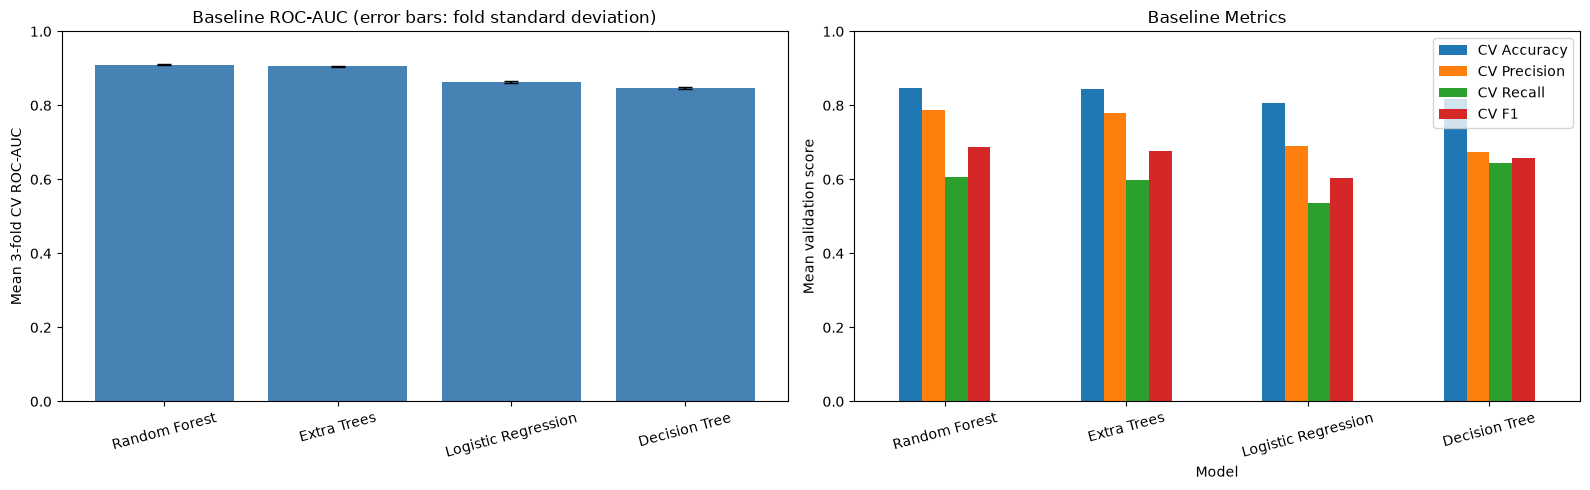

In [60]:
# Baseline comparison: ranking performance and threshold-based metrics.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(
    baseline_results['Model'], baseline_results['CV ROC-AUC mean'],
    yerr=baseline_results['CV ROC-AUC std'], capsize=5, color='steelblue'
)
axes[0].set(ylim=(0, 1), ylabel='Mean 3-fold CV ROC-AUC',
            title='Baseline ROC-AUC (error bars: fold standard deviation)')
baseline_results.set_index('Model')[
    ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1']
].plot.bar(ax=axes[1], ylim=(0, 1), rot=15)
axes[1].set(title='Baseline Metrics', ylabel='Mean validation score')
axes[0].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## Stage 7: Model Optimization and Final Selection

Hyperparameter search uses training data and the same stratified folds. The held-out Stage 5 test set is used only after selecting the final model.

In [61]:
# Stage 7 - Randomized hyperparameter search for Random Forest
from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocess', clone(model_preprocessor)),
        ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    param_distributions={
        'model__n_estimators': [100, 160],
        'model__max_depth': [None, 20],
        'model__min_samples_leaf': [2, 5, 10],
        'model__max_features': ['sqrt', 0.7]
    },
    n_iter=4,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    random_state=42,
    refit=True,
    error_score='raise'
)
rf_search.fit(X_model_train, y_train)

print('Best Random Forest parameters:', rf_search.best_params_)
print('Best training CV ROC-AUC:', round(rf_search.best_score_, 4))


Best Random Forest parameters: {'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20}
Best training CV ROC-AUC: 0.9125


In [62]:
# Stage 7 - Grid search for Logistic Regression
from sklearn.model_selection import GridSearchCV

lr_search = GridSearchCV(
    estimator=Pipeline([
        ('preprocess', clone(model_preprocessor)),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    param_grid={
        'model__C': [0.3, 1.0, 3.0],
        'model__class_weight': [None, 'balanced']
    },
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    refit=True,
    error_score='raise'
)
lr_search.fit(X_model_train, y_train)

print('Best Logistic Regression parameters:', lr_search.best_params_)
print('Best training CV ROC-AUC:', round(lr_search.best_score_, 4))


Best Logistic Regression parameters: {'model__C': 3.0, 'model__class_weight': 'balanced'}
Best training CV ROC-AUC: 0.8644


In [63]:
# Compare baseline and tuned candidates using training-only CV ROC-AUC
comparison_rows = [
    {
        'Model': f'Baseline {row["Model"]}',
        'CV ROC-AUC': row['CV ROC-AUC mean'],
        'Type': 'Baseline'
    }
    for _, row in baseline_results.iterrows()
]
comparison_rows.extend([
    {'Model': 'Tuned Random Forest', 'CV ROC-AUC': rf_search.best_score_, 'Type': 'Tuned'},
    {'Model': 'Tuned Logistic Regression', 'CV ROC-AUC': lr_search.best_score_, 'Type': 'Tuned'}
])
model_comparison = pd.DataFrame(comparison_rows).sort_values(
    'CV ROC-AUC', ascending=False
).reset_index(drop=True)
display(model_comparison.round(4))

,Model,CV ROC-AUC,Type
0,Tuned Random Forest,0.9125,Tuned
1,Baseline Random Forest,0.9097,Baseline
2,Baseline Extra Trees,0.9058,Baseline
3,Tuned Logistic Regression,0.8644,Tuned
4,Baseline Logistic Regression,0.8640,Baseline
5,Baseline Decision Tree,0.8476,Baseline


In [64]:
# Select the highest-CV-ROC-AUC candidate and refit it on all training rows
candidate_pipelines = {
    'Baseline Logistic Regression': baseline_pipelines['Logistic Regression'],
    'Baseline Decision Tree': baseline_pipelines['Decision Tree'],
    'Baseline Random Forest': baseline_pipelines['Random Forest'],
    'Baseline Extra Trees': baseline_pipelines['Extra Trees'],
    'Tuned Random Forest': rf_search.best_estimator_,
    'Tuned Logistic Regression': lr_search.best_estimator_
}
selected_name = model_comparison.loc[0, 'Model']
selected_cv_auc = model_comparison.loc[0, 'CV ROC-AUC']
final_model = clone(candidate_pipelines[selected_name]).fit(X_model_train, y_train)

print('Selected model:', selected_name)
print('Training CV ROC-AUC:', round(selected_cv_auc, 4))
print('Final model refit on all Stage 5 training rows; test set remains unused.')

Selected model: Tuned Random Forest
Training CV ROC-AUC: 0.9125
Final model refit on all Stage 5 training rows; test set remains unused.


In [65]:
# Feature ablation reuses the same preprocessing templates and CV folds.
engineered_features = [
    'total_nights', 'is_long_stay', 'is_weekend_stay', 'is_high_lead_time'
]
X_train_without_engineering = X_model_train.drop(columns=engineered_features)
ablated_numeric_features = [
    column for column in numeric_features if column not in engineered_features
]
ablated_pipeline = Pipeline([
    ('preprocess', ColumnTransformer([
        ('numeric', clone(model_numeric_transformer), ablated_numeric_features),
        ('categorical', clone(model_categorical_transformer), categorical_features)
    ])),
    ('model', clone(final_model.named_steps['model']))
])
ablation_scores = cross_validate(
    ablated_pipeline, X_train_without_engineering, y_train,
    cv=cv, scoring='roc_auc', n_jobs=1, error_score='raise'
)
ablated_cv_auc = ablation_scores['test_score'].mean()
display(pd.DataFrame({
    'Feature set': ['With engineered features', 'Without engineered features'],
    'CV ROC-AUC': [selected_cv_auc, ablated_cv_auc]
}).round(4))
print('Engineering AUC difference:', round(selected_cv_auc - ablated_cv_auc, 4))


,Feature set,CV ROC-AUC
0,With engineered features,0.9125
1,Without engineered features,0.9126


Engineering AUC difference: -0.0001


In [66]:
# Final held-out evaluation: only after selecting the best model with training CV.
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import FunctionTransformer

deployment_model = Pipeline([
    ('normalize_identifiers', Pipeline([
        ('fill_missing_ids', FunctionTransformer(
            pd.DataFrame.fillna, kw_args={'value': {'agent': 0, 'company': 0}}, validate=False
        )),
        ('string_ids', FunctionTransformer(
            pd.DataFrame.astype, kw_args={'dtype': {'agent': str, 'company': str}}, validate=False
        ))
    ])),
    ('classifier', final_model)
])
y_test_pred = deployment_model.predict(X_test)
y_test_probability = deployment_model.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
test_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1',
               'ROC-AUC', 'Average Precision', 'Specificity', 'MCC'],
    'Score': [
        accuracy_score(y_test, y_test_pred),
        balanced_accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_probability),
        average_precision_score(y_test, y_test_probability),
        tn / (tn + fp) if tn + fp else 0.0,
        matthews_corrcoef(y_test, y_test_pred)
    ]
})
print('Selected model:', selected_name)
display(test_metrics.round(4))
print(classification_report(
    y_test, y_test_pred, labels=[0, 1],
    target_names=['Not canceled', 'Canceled'], zero_division=0
))
display(pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual not canceled', 'Actual canceled'],
    columns=['Predicted not canceled', 'Predicted canceled']
))


Selected model: Tuned Random Forest


,Metric,Score
0,Accuracy,0.8508
1,Balanced Accuracy,0.7972
2,Precision,0.7543
3,Recall,0.6780
4,F1,0.7142
5,ROC-AUC,0.9158
6,Average Precision,0.8123
7,Specificity,0.9163
8,MCC,0.6152


              precision    recall  f1-score   support

Not canceled       0.88      0.92      0.90     12675
    Canceled       0.75      0.68      0.71      4805

    accuracy                           0.85     17480
   macro avg       0.82      0.80      0.81     17480
weighted avg       0.85      0.85      0.85     17480



,Predicted not canceled,Predicted canceled
Actual not canceled,11614,1061
Actual canceled,1547,3258


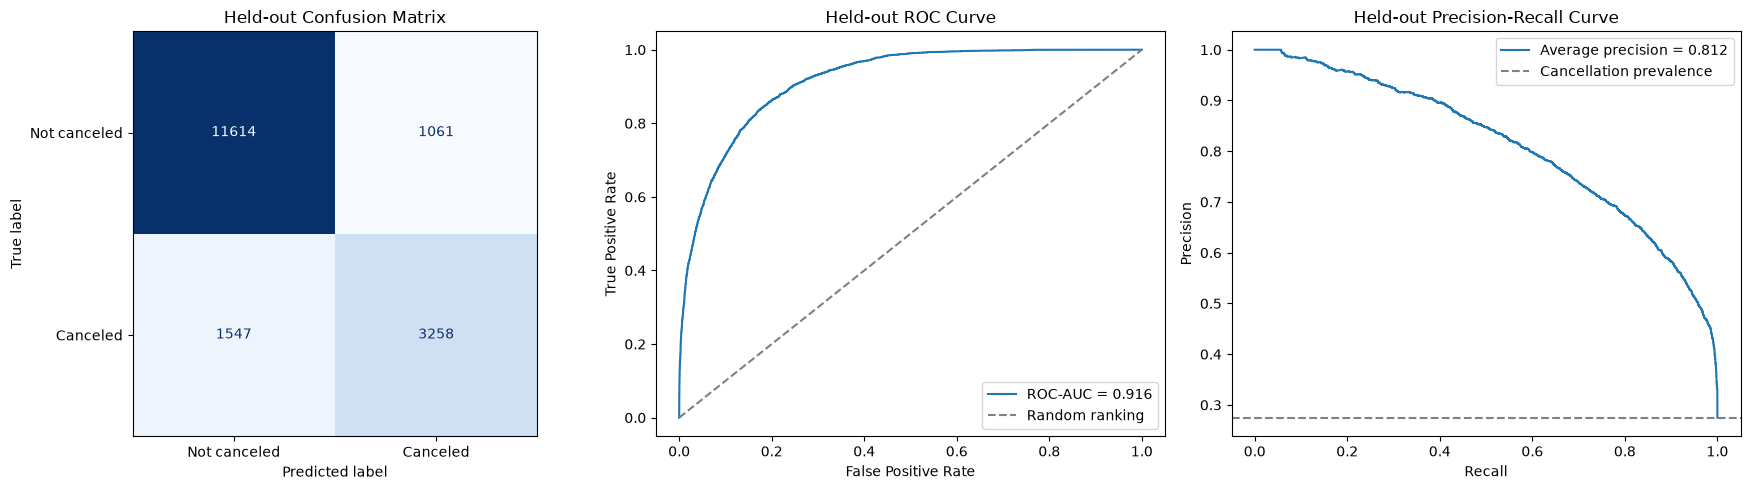

In [67]:
# Visual evaluation: confusion matrix, ROC, and precision-recall curves.
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, labels=[0, 1],
    display_labels=['Not canceled', 'Canceled'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Held-out Confusion Matrix')
fpr, tpr, _ = roc_curve(y_test, y_test_probability)
axes[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_test_probability):.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='grey', label='Random ranking')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='Held-out ROC Curve')
axes[1].legend()
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_test_probability)
axes[2].plot(pr_recall, pr_precision,
             label=f'Average precision = {average_precision_score(y_test, y_test_probability):.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='grey', label='Cancellation prevalence')
axes[2].set(xlabel='Recall', ylabel='Precision', title='Held-out Precision-Recall Curve')
axes[2].legend()
plt.tight_layout()
plt.show()


In [68]:
# Save the selected fitted pipeline and metadata; verify the reloaded model.
import joblib
from pathlib import Path

model_artifact_path = Path('best_hotel_cancellation_model.joblib')
model_artifact = {
    'model': deployment_model,
    'selected_model': selected_name,
    'target': 'is_canceled',
    'feature_columns': X_model_train.columns.tolist(),
    'classification_threshold': 0.5,
    'training_cv_roc_auc': float(selected_cv_auc),
    'test_metrics': dict(zip(test_metrics['Metric'], test_metrics['Score'])),
    'input_description': 'Stage 5 cleaned booking features, including engineered columns'
}
joblib.dump(model_artifact, model_artifact_path, compress=3)
loaded_artifact = joblib.load(model_artifact_path)
verification_row = X_test.iloc[[0]].copy()
assert np.array_equal(
    deployment_model.predict(verification_row),
    loaded_artifact['model'].predict(verification_row)
)
assert np.allclose(
    deployment_model.predict_proba(verification_row),
    loaded_artifact['model'].predict_proba(verification_row)
)
print('Saved and verified:', model_artifact_path.resolve())
print('Saved pipeline uses built-in pandas operations; no custom helper file is required.')


Saved and verified: C:\Users\ADMIN\Desktop\FDM\best_hotel_cancellation_model.joblib
Saved pipeline uses built-in pandas operations; no custom helper file is required.


In [69]:
# Test ONE held-out booking using the saved/reloaded best model.
sample_position = 0
sample_booking = X_test.iloc[[sample_position]].copy()
sample_prediction = int(loaded_artifact['model'].predict(sample_booking)[0])
sample_cancellation_probability = float(
    loaded_artifact['model'].predict_proba(sample_booking)[0, 1]
)
sample_actual = int(y_test.iloc[sample_position])
print('Booking input (all required features):')
display(sample_booking.T.rename(columns={sample_booking.index[0]: 'Value'}))
sample_result = pd.DataFrame([{
    'Booking index': sample_booking.index[0],
    'Actual outcome': 'Canceled' if sample_actual == 1 else 'Not canceled',
    'Predicted outcome': 'Likely to cancel' if sample_prediction == 1 else 'Not likely to cancel',
    'Cancellation probability': round(sample_cancellation_probability, 4),
    'Prediction correct': sample_prediction == sample_actual
}])
display(sample_result)
print(f'Cancellation probability: {sample_cancellation_probability:.2%}')


Booking input (all required features):


,Value
hotel,City Hotel
lead_time,243
arrival_date_year,2017
arrival_date_month,August
arrival_date_week_number,31
arrival_date_day_of_month,4
stays_in_weekend_nights,0
stays_in_week_nights,1
adults,2
children,0.0


,Booking index,Actual outcome,Predicted outcome,Cancellation probability,Prediction correct
0,117514,Not canceled,Not likely to cancel,0.2267,True


Cancellation probability: 22.67%


## Stage 8: Progress Evaluation 2 — Interpretation

Use the executed tables above for current results. Select the best model using
training-only CV ROC-AUC, then evaluate it on the held-out Stage 5 test partition.

- Accuracy measures overall correct labels; balanced accuracy averages class recalls.
- Precision measures correct cancellation alerts; recall measures cancellations detected.
- F1 balances precision and recall. Specificity measures non-canceled bookings correctly identified.
- ROC-AUC measures ranking across thresholds. Average precision summarizes precision-recall performance.
- MCC summarizes all four confusion-matrix entries; values closer to 1 indicate stronger classification.
- The confusion matrix shows exact errors. ROC and precision-recall plots show threshold trade-offs.
- The ablation compares engineered features with their removal using the same classifier settings and folds.
- The saved artifact includes preprocessing and model metadata. It expects the cleaned/engineered Stage 5
  input schema; it is not a complete raw-booking cleaning service.
- Identifier normalization uses built-in pandas operations; no custom function or helper file is required.
- Existing early median filling was completed before the split; that remains an evaluation limitation.

For the viva, explain the selected model, tuning choices, validation strategy, error types,
and one limitation. Do not describe a probability as a guaranteed outcome.
